# Mood Space Interpolation Demo

This notebook demonstrates how to:
1. Train a Mood Space compression model on two images
2. Interpolate between the images using the trained model
3. Visualize the interpolation results

The demo uses Jimi Hendrix images to show smooth transitions between portrait and action poses.

In [1]:
# Import required libraries
import torch
from PIL import Image
import numpy as np
import skdim
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

import sys
from app import (
    train_mood_space,
    perform_two_image_interpolation,
    perform_two_image_interpolation_input_space,
    interpolate_two_images_no_compression,
    compute_direction_from_two_images,
    load_config
)
from extract_features import (
    dino_image_transform,
    clip_image_transform,
    extract_dino_features,
    extract_clip_features
)
from dino_correspondence import kway_cluster_per_image, match_centers_two_images, get_cluster_center_features

def create_image_grid(images, rows, cols):
    """
    Create a grid layout of images.
    
    Args:
        images: List of PIL Images
        rows: Number of rows in the grid
        cols: Number of columns in the grid
    
    Returns:
        PIL.Image: Grid image
    """
    assert len(images) == rows * cols, f"Expected {rows*cols} images, got {len(images)}"

    # Get dimensions from first image
    width, height = images[0].size
    
    # Create empty grid canvas
    grid = Image.new('RGB', size=(cols * width, rows * height))
    
    # Paste each image into the grid
    for i, img in enumerate(images):
        x_pos = (i % cols) * width
        y_pos = (i // cols) * height
        grid.paste(img, box=(x_pos, y_pos))
    
    return grid

## Load and Prepare Images

Load the two Jimi Hendrix images and resize them to a consistent size for processing.

Loaded images: (512, 512) and (512, 512)
Input Images:


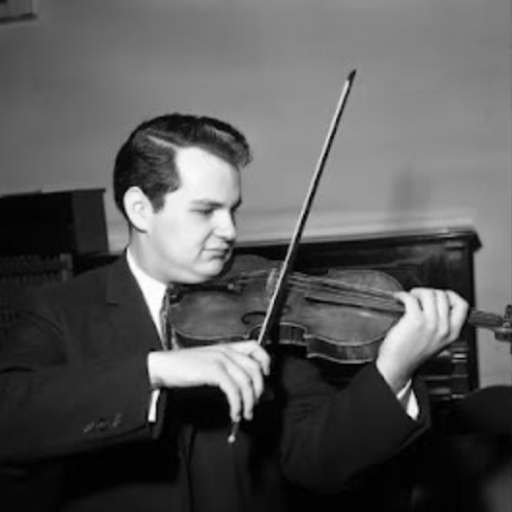

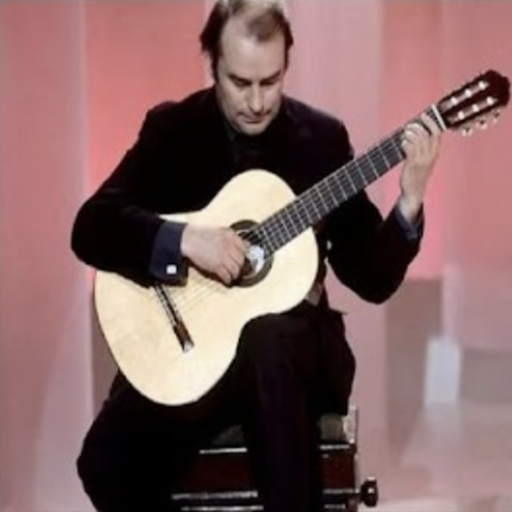

In [2]:
# Load and prepare input images
path1 = "./images/playviolin.png"
path2 = "./images/playguitar.png"
# path1 = "./images/easy_vs_hard/hard2a.png"
# path2 = "./images/easy_vs_hard/hard2b.png"

# Resize images to consistent size
image1 = Image.open(path1).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")
image2 = Image.open(path2).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")

print(f"Loaded images: {image1.size} and {image2.size}")

# Display the input images
print("Input Images:")
display(image1)
display(image2)

## Train Mood Space Model

Train a neural compression model that learns to compress the image features while preserving semantic relationships.

In [3]:
# Train the Mood Space compression model
print("Training Mood Space model...")
model, trainer = train_mood_space(
    pil_images=[image1, image2], 
    learning_rate=0.001, 
    training_steps=1000,
    mlp_width=512,
    mlp_layers=2
)

print("Training completed!")

Training Mood Space model...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Training: |          | 0/? [00:00<?, ?it/s]

Training completed!


## Generate Interpolation

Create a smooth interpolation between the two images using the trained model.

In [4]:
# Define interpolation weights (0.0 = image1, 1.0 = image2)
interpolation_weights = np.linspace(0.0, 1.0, 11).tolist()
print(f"Interpolation weights: {interpolation_weights}")

# Generate interpolated images
print("Generating interpolated images...")
interpolated_images = perform_two_image_interpolation(
    image1=image1, 
    image2=image2, 
    model=model, 
    interpolation_weights=interpolation_weights,
    n_clusters=10, 
    match_method='hungarian',
    use_dino_matching=False,
    seed=42
)

Interpolation weights: [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Generating interpolated images...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Creating grid with 13 images...

Interpolation Results Mood Space:


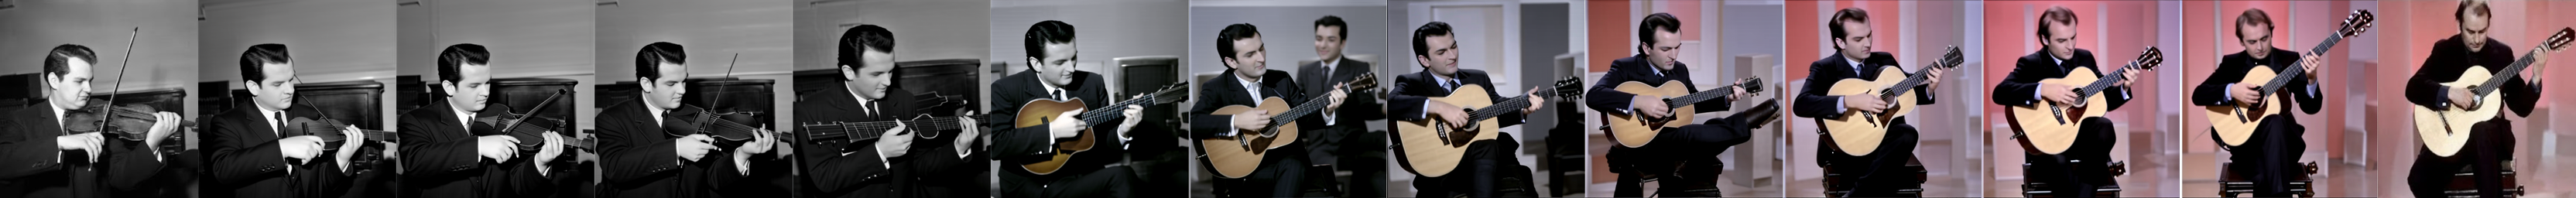

In [5]:
# Combine original images with interpolated results
all_images = [image1] + interpolated_images + [image2]

# Resize images for better display
display_size = (256, 256)
resized_images = [img.resize(display_size, Image.Resampling.LANCZOS) for img in all_images]

# Create and display the grid
print(f"Creating grid with {len(all_images)} images...")
result_grid = create_image_grid(resized_images, 1, len(resized_images))

print("\nInterpolation Results Mood Space:")
display(result_grid)

In [6]:
# Define interpolation weights (0.0 = image1, 1.0 = image2)
interpolation_weights = np.linspace(0.0, 1.0, 11).tolist()
print(f"Interpolation weights: {interpolation_weights}")

# Generate interpolated images
print("Generating interpolated images...")
interpolated_images_no_compression = interpolate_two_images_no_compression(
    image1=image1, 
    image2=image2, 
    interpolation_weights=interpolation_weights,
    n_clusters=10, 
    match_method='hungarian',
    dino_matching=False,
    seed=42
)

print(f"Generated {len(interpolated_images_no_compression)} interpolated images")

Interpolation weights: [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Generating interpolated images...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generated 11 interpolated images


Creating grid with 13 images...

Interpolation Results Clip Linear:


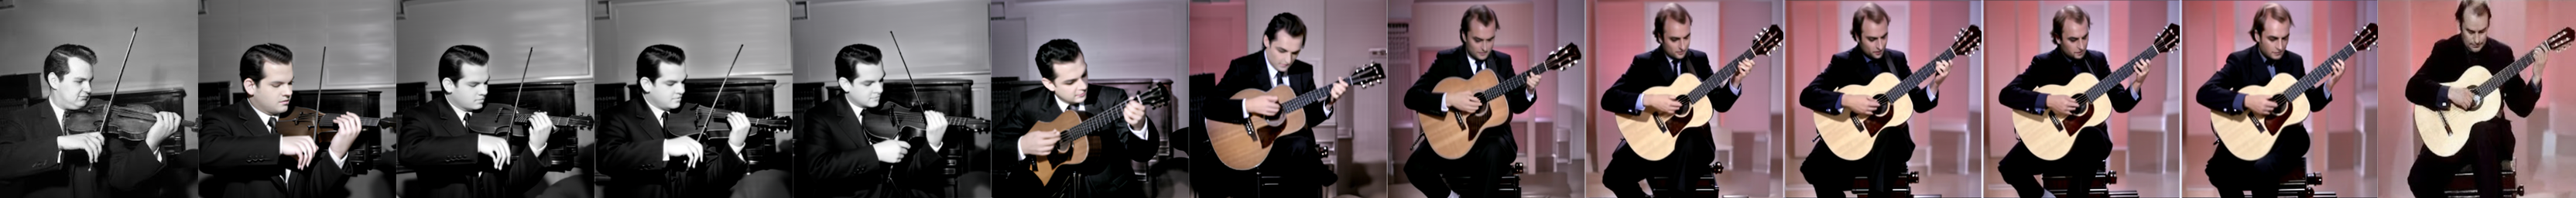

In [7]:
# Combine original images with interpolated results (no compression)
all_images_no_compression = [image1] + interpolated_images_no_compression + [image2]

# Resize images for better display
resized_images_no_compression = [img.resize(display_size, Image.Resampling.LANCZOS) for img in all_images_no_compression]

# Create and display the grid
print(f"Creating grid with {len(all_images_no_compression)} images...")
result_grid_no_compression = create_image_grid(resized_images_no_compression, 1, len(resized_images_no_compression))

print("\nInterpolation Results Clip Linear:")
display(result_grid_no_compression)

Computing path curvature metrics...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Using direct token interpolation for direction fields.
Mood path length: 684.65
Clip path length: 393.87
Length ratio (mood / clip): 1.74
Mean direction change (mood): 17.89°
Max direction change (mood): 19.72°
Mean direction change (clip): 0.01°
Max direction change (clip): 0.03°


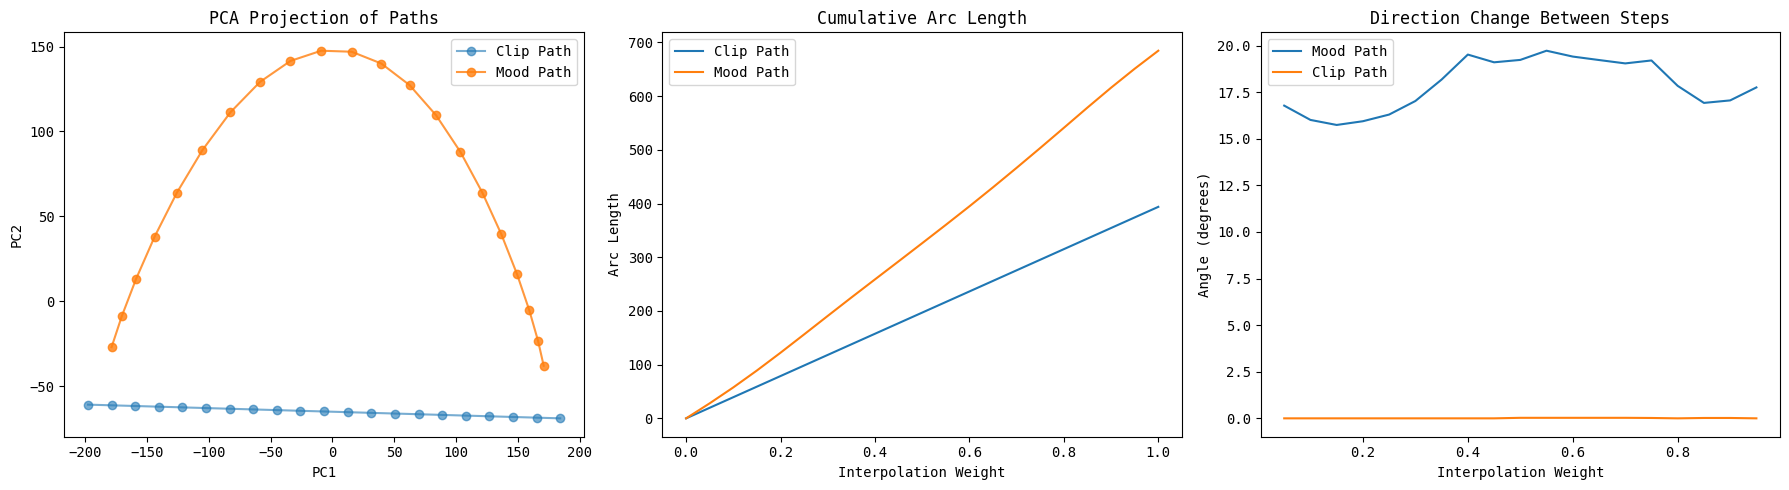

In [8]:
# Analyze curvature between mood-space and clip-space interpolation paths
print("Computing path curvature metrics...")
interpolation_weights = np.linspace(0.0, 1.0, 21).tolist()
use_cluster_correspondence = False  # Toggle to disable DINO correspondence and use direct token interpolation instead

def _flatten_embeddings(tensor):
    return tensor.reshape(tensor.shape[0], -1).cpu().numpy()

def _downsample_cluster_labels(cluster_labels, downsample_factor=2):
    cls_token = cluster_labels[:1]
    spatial_labels = cluster_labels[1:]
    spatial_size = int(spatial_labels.shape[0] ** 0.5)
    if spatial_size * spatial_size != spatial_labels.shape[0]:
        raise ValueError("Spatial portion of cluster labels must form a square grid")
    if spatial_size % downsample_factor != 0:
        raise ValueError("Downsample factor must evenly divide spatial grid size")
    spatial_grid = spatial_labels.reshape(spatial_size, spatial_size)
    new_size = spatial_size // downsample_factor
    pooled = []
    for i in range(new_size):
        for j in range(new_size):
            patch = spatial_grid[
                i * downsample_factor:(i + 1) * downsample_factor,
                j * downsample_factor:(j + 1) * downsample_factor
]
            pooled.append(torch.mode(patch.flatten(), keepdim=False).values)
    pooled = torch.stack(pooled)
    return torch.cat([cls_token, pooled])

def _build_direction_field(direction_vectors, cluster_labels):
    cluster_labels = cluster_labels.long()
    return direction_vectors[cluster_labels]

with torch.no_grad():
    config = load_config("./config.yaml")
    clip_inputs = torch.stack([clip_image_transform(img) for img in [image1, image2]])
    dino_inputs = torch.stack([dino_image_transform(img) for img in [image1, image2]])
    dino_embeds = extract_dino_features(dino_inputs)
    clip_embeds = extract_clip_features(clip_inputs, ipadapter_version=config.ipadapter_version)

    model_device = next(model.parameters()).device
    dino_embeds_device = dino_embeds.to(model_device)
    compressed_embeds = model.encoder(dino_embeds_device)

    if use_cluster_correspondence:
        cluster_eigvecs = kway_cluster_per_image(dino_embeds_device, n_clusters=10, gamma=None)
        cluster_mapping = match_centers_two_images(
            dino_embeds_device[0].cpu(), dino_embeds_device[1].cpu(),
            cluster_eigvecs[0].cpu(), cluster_eigvecs[1].cpu(),
            match_method='hungarian'
        )
        cluster_mapping = np.asarray(cluster_mapping)

        mood_direction_vectors = compute_direction_from_two_images(
            compressed_embeds, cluster_eigvecs, cluster_mapping, use_unit_norm=False, return_direction_vectors=True
        )
        cluster_labels_a = cluster_eigvecs[0].argmax(-1)
        mood_direction_field = _build_direction_field(mood_direction_vectors, cluster_labels_a)

        cluster_labels_a_cpu = cluster_labels_a.cpu()
        cluster_labels_b_cpu = cluster_eigvecs[1].argmax(-1).cpu()
        cluster_labels_a_clip = _downsample_cluster_labels(cluster_labels_a_cpu)
        cluster_labels_b_clip = _downsample_cluster_labels(cluster_labels_b_cpu)

        clip_centers_a = get_cluster_center_features(clip_embeds[0], cluster_labels_a_clip, cluster_eigvecs.shape[-1])
        clip_centers_b = get_cluster_center_features(clip_embeds[1], cluster_labels_b_clip, cluster_eigvecs.shape[-1])
        clip_direction_vectors = []
        for idx_a, idx_b in enumerate(cluster_mapping):
            direction = clip_centers_b[idx_b] - clip_centers_a[idx_a]
            clip_direction_vectors.append(direction)
        clip_direction_vectors = torch.stack(clip_direction_vectors)
        clip_direction_field = _build_direction_field(clip_direction_vectors, cluster_labels_a_clip)
    else:
        cluster_eigvecs = None  # Explicitly note unused in this branch
        mood_direction_field = compressed_embeds[1] - compressed_embeds[0]
        clip_direction_field = clip_embeds[1] - clip_embeds[0]

    mood_path_tensors = []
    clip_path_tensors = []
    for weight in interpolation_weights:
        interpolated_compressed = compressed_embeds[0] + mood_direction_field * weight
        decoded_clip = model.decoder(interpolated_compressed)
        mood_path_tensors.append(decoded_clip.detach().cpu())

        interpolated_clip = clip_embeds[0] + clip_direction_field * weight
        clip_path_tensors.append(interpolated_clip.detach().cpu())

    mood_path_tensors = torch.stack(mood_path_tensors)
    clip_path_tensors = torch.stack(clip_path_tensors)

mood_flat = _flatten_embeddings(mood_path_tensors)
clip_flat = _flatten_embeddings(clip_path_tensors)

def _segment_lengths(flat_embeddings):
    diffs = np.diff(flat_embeddings, axis=0)
    lengths = np.linalg.norm(diffs, axis=1)
    return diffs, lengths

def _direction_changes(diffs, lengths):
    if len(diffs) < 2:
        return np.array([])
    eps = 1e-12
    norm_dirs = diffs / np.clip(lengths[:, None], eps, None)
    dot_products = np.sum(norm_dirs[:-1] * norm_dirs[1:], axis=1)
    dot_products = np.clip(dot_products, -1.0, 1.0)
    return np.degrees(np.arccos(dot_products))

mood_diffs, mood_lengths = _segment_lengths(mood_flat)
clip_diffs, clip_lengths = _segment_lengths(clip_flat)

total_length_mood = mood_lengths.sum()
total_length_clip = clip_lengths.sum()
length_ratio = total_length_mood / total_length_clip if total_length_clip > 0 else np.nan

mood_direction_changes = _direction_changes(mood_diffs, mood_lengths)
clip_direction_changes = _direction_changes(clip_diffs, clip_lengths)

cumulative_mood = np.concatenate(([0.0], np.cumsum(mood_lengths)))
cumulative_clip = np.concatenate(([0.0], np.cumsum(clip_lengths)))

path_mode = "cluster correspondence" if use_cluster_correspondence else "direct token interpolation"
print(f"Using {path_mode} for direction fields.")
print(f"Mood path length: {total_length_mood:.2f}")
print(f"Clip path length: {total_length_clip:.2f}")
print(f"Length ratio (mood / clip): {length_ratio:.2f}")
if len(mood_direction_changes) > 0:
    print(f"Mean direction change (mood): {mood_direction_changes.mean():.2f}°")
    print(f"Max direction change (mood): {mood_direction_changes.max():.2f}°")
if len(clip_direction_changes) > 0:
    print(f"Mean direction change (clip): {clip_direction_changes.mean():.2f}°")
    print(f"Max direction change (clip): {clip_direction_changes.max():.2f}°")

weights_array = np.array(interpolation_weights)
pca = PCA(n_components=2)
joint_projection = pca.fit_transform(np.concatenate([mood_flat, clip_flat], axis=0))
proj_mood = joint_projection[:len(weights_array)]
proj_clip = joint_projection[len(weights_array):]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(proj_clip[:, 0], proj_clip[:, 1], 'o-', label='Clip Path', alpha=0.6)
axes[0].plot(proj_mood[:, 0], proj_mood[:, 1], 'o-', label='Mood Path', alpha=0.8)
axes[0].set_title('PCA Projection of Paths')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].plot(weights_array, cumulative_clip, label='Clip Path')
axes[1].plot(weights_array, cumulative_mood, label='Mood Path')
axes[1].set_title('Cumulative Arc Length')
axes[1].set_xlabel('Interpolation Weight')
axes[1].set_ylabel('Arc Length')
axes[1].legend()

mid_weights = weights_array[1:-1]
axes[2].plot(mid_weights, mood_direction_changes, label='Mood Path')
axes[2].plot(mid_weights, clip_direction_changes, label='Clip Path')
axes[2].set_title('Direction Change Between Steps')
axes[2].set_xlabel('Interpolation Weight')
axes[2].set_ylabel('Angle (degrees)')
axes[2].legend()

plt.tight_layout()
plt.show()